# 高斯混合模型 (GMM) 实战：鸢尾花 (Iris) 数据集聚类

## 1. 案例背景

鸢尾花数据集 (Iris Dataset) 是机器学习领域最经典的数据集之一。它包含 150 个样本，分为 3 个品种：
- Setosa (山鸢尾)
- Versicolor (变色鸢尾)
- Virginica (维吉尼亚鸢尾)

每个样本有 4 个特征：花萼长度、花萼宽度、花瓣长度、花瓣宽度。

**任务**：假设我们不知道样本的标签（品种），我们能否使用 **GMM** 将这些样本自动聚类成 3 组，并观察聚类结果与真实品种的吻合程度？

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LogNorm

# 设置绘图风格
sns.set_style("whitegrid")

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 数据加载与预处理

为了便于可视化，我们只选取其中两个特征：**花瓣长度 (Petal Length)** 和 **花瓣宽度 (Petal Width)**。这两个特征对品种的区分度较高。

In [3]:
# 加载数据
iris = load_iris()
X = iris.data[:, 2:]  # 只取最后两个特征：花瓣长度、花瓣宽度
y_true = iris.target  # 真实标签（仅用于对比，不参与训练）
feature_names = iris.feature_names[2:]

print(f"特征名称: {feature_names}")
print(f"数据形状: {X.shape}")

# 数据标准化（对于基于距离/方差的模型很重要，虽然 GMM 对缩放不那么敏感，但标准化有助于数值稳定性）
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# 注：为了保持原始数据的物理意义（厘米），这里暂不进行标准化，直接使用原始数据演示

特征名称: ['petal length (cm)', 'petal width (cm)']
数据形状: (150, 2)


## 3. 训练 GMM 模型

我们将混合成分数量 ($) 设为 3，对应 3 个鸢尾花品种。

In [4]:
# 初始化 GMM 模型
gmm = GaussianMixture(n_components=3, random_state=42)

# 训练模型
gmm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [6]:
# 输出模型参数
print("GMM 模型参数估计结果：")
print("-" * 30)
for i in range(3):
    print(f"Cluster {i+1}:")
    print(f"  权重 (Weight): {gmm.weights_[i]:.4f}")
    print(f"  均值 (Mean):   {gmm.means_[i]}")
    print(f"  协方差 (Covariance):{gmm.covariances_[i]}")

GMM 模型参数估计结果：
------------------------------
Cluster 1:
  权重 (Weight): 0.3147
  均值 (Mean):   [5.57721357 2.04303224]
  协方差 (Covariance):[[0.30034404 0.04402642]
 [0.04402642 0.07200287]]
Cluster 2:
  权重 (Weight): 0.3333
  均值 (Mean):   [1.4619995  0.24599977]
  协方差 (Covariance):[[0.02955684 0.00594793]
 [0.00594793 0.01088496]]
Cluster 3:
  权重 (Weight): 0.3520
  均值 (Mean):   [4.30594388 1.34787855]
  协方差 (Covariance):[[0.24667113 0.08489919]
 [0.08489919 0.04585075]]


## 4. 结果可视化

我们不仅展示聚类结果，还将绘制 GMM 的**等高线 (Contours)**，直观展示模型学习到的概率密度分布。

/tmp/ipykernel_65983/1762821006.py:13: UserWarning: Log scale: values of z <= 0 have been masked
  CS = plt.contour(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=1000.0),


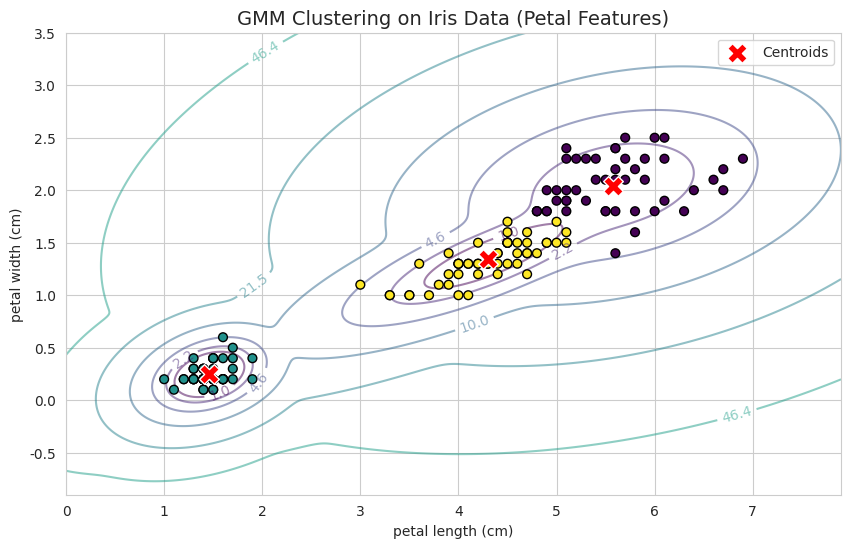

In [7]:
def plot_gmm_results(X, gmm, title="GMM Clustering"):
    # 1. 生成网格数据用于绘制等高线
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), 
                         np.linspace(y_min, y_max, 500))
    Z = -gmm.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    
    # 2. 绘制等高线
    CS = plt.contour(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=1000.0),
                     levels=np.logspace(0, 3, 10), cmap='viridis', alpha=0.5)
    plt.clabel(CS, inline=1, fontsize=10)
    
    # 3. 绘制散点图（按预测类别着色）
    labels = gmm.predict(X)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2, edgecolors='k')
    
    # 4. 标记聚类中心
    plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', s=200, marker='X', 
                label='Centroids', zorder=3, edgecolors='white')

    plt.title(title, fontsize=14)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.legend()
    plt.show()

plot_gmm_results(X, gmm, title="GMM Clustering on Iris Data (Petal Features)")

## 5. 软聚类 (Soft Clustering) 演示

GMM 的一大优势是能给出每个样本属于各个簇的概率。让我们看几个样本的概率分布。

In [9]:
# 获取所有样本的后验概率
probs = gmm.predict_proba(X)

# 挑选几个具有代表性的样本（例如概率最大的类别概率 < 0.8 的样本，说明比较模棱两可）
uncertain_indices = np.where(probs.max(axis=1) < 0.9)[0]

print(f"发现 {len(uncertain_indices)} 个分类置信度较低 (<90%) 的样本。")

if len(uncertain_indices) > 0:
    print(f"{'样本索引':<10} | {'簇 0 概率':<10} | {'簇 1 概率':<10} | {'簇 2 概率':<10}")
    print("-" * 50)
    for idx in uncertain_indices[:5]:  # 只显示前5个
        p = probs[idx]
        print(f"{idx:<10} | {p[0]:.4f}     | {p[1]:.4f}     | {p[2]:.4f}")
else:
    print("所有样本的分类置信度都很高。")

发现 14 个分类置信度较低 (<90%) 的样本。
样本索引       | 簇 0 概率     | 簇 1 概率     | 簇 2 概率    
--------------------------------------------------
70         | 0.7022     | 0.0000     | 0.2978
77         | 0.3547     | 0.0000     | 0.6453
83         | 0.2601     | 0.0000     | 0.7399
103        | 0.8845     | 0.0000     | 0.1155
106        | 0.3623     | 0.0000     | 0.6377
